# Stochastic Gradient Descent on Linear Regression

Our goal is to build a model that will help you predict the best time to go to the gym and avoid crowds, so we can enjoy a great workout with minimal wait times and no crowds.

We wil be using the “Crowdedness at the Campus Gym” dataset, which contains historic information about how crowded the campus gym is on a given day and hour, as well as other specific information about the specific days.

This dataset contains over `60,000` observations about how many people were at the gym on a particular day and time

## Explore the dataset.

In [1]:
# import necessary library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Read the dataset
gym = pd.read_csv('../../dataset/crowdness_gym_data.csv')
gym.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [3]:
# check the shape of the dataset
gym.shape

(62184, 11)

In [4]:
gym.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB


In [5]:
gym.isna().sum()

number_people           0
date                    0
timestamp               0
day_of_week             0
is_weekend              0
is_holiday              0
temperature             0
is_start_of_semester    0
is_during_semester      0
month                   0
hour                    0
dtype: int64

In [6]:
gym.describe()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
count,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000
mean,29.072543,45799.437958,2.982504,0.282870,0.002573,58.557108,0.078831,0.660218,7.439824,12.236460
std,22.689026,24211.275891,1.996825,0.450398,0.050660,6.316396,0.269476,0.473639,3.445069,6.717631
min,0.000000,0.000000,0.000000,0.000000,0.000000,38.140000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,26624.000000,1.000000,0.000000,0.000000,55.000000,0.000000,0.000000,5.000000,7.000000
50%,28.000000,46522.500000,3.000000,0.000000,0.000000,58.340000,0.000000,1.000000,8.000000,12.000000
75%,43.000000,66612.000000,5.000000,1.000000,0.000000,62.280000,0.000000,1.000000,10.000000,18.000000
max,145.000000,86399.000000,6.000000,1.000000,1.000000,87.170000,1.000000,1.000000,12.000000,23.000000


- There are `62184` observations in the dataset and `11` feature columns.
- There are only 1 object column i.e date which will be problematic for further analysis so remove this columns as other columns can be used for analysis.
- some of the features like **is_holiday**, **is_start_of_semester**, **is_during_semester**, and **is_weekend** are binary features.
- No missing values are found in the dataset.
- On average, there are `23` people in the gym. But we know that in night time the count will be significantly less.

In [7]:
# Remove the date column from DataFrame
gym = gym.drop('date', axis = 1)
gym.head()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,61211,4,0,0,71.76,0,0,8,17
1,45,62414,4,0,0,71.76,0,0,8,17
2,40,63015,4,0,0,71.76,0,0,8,17
3,44,63616,4,0,0,71.76,0,0,8,17
4,45,64217,4,0,0,71.76,0,0,8,17


Let's do some EDA on the dataset.
We will start by doing some univariate analysis of the variable.

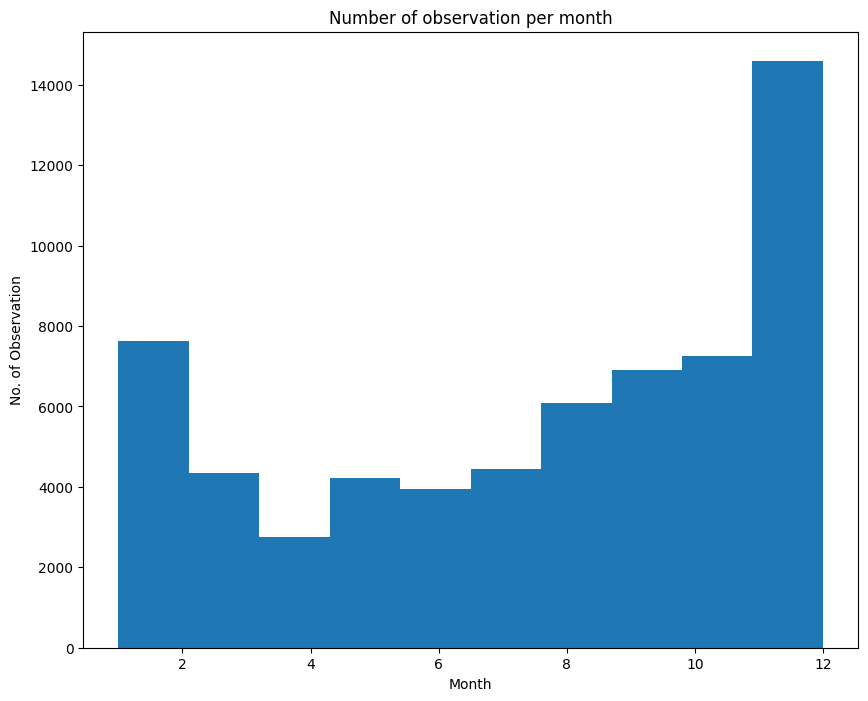

In [8]:
# plot the histogram of month column
plt.figure(figsize= (10,8))
plt.hist(gym['month'])
plt.title('Number of observation per month')
plt.xlabel('Month')
plt.ylabel('No. of Observation')
plt.show()


- Most of the observation are in december and january month. This might suggest people are more interested in joining gym in start of the year.
- Most people left the gym after 1 or 2 month.

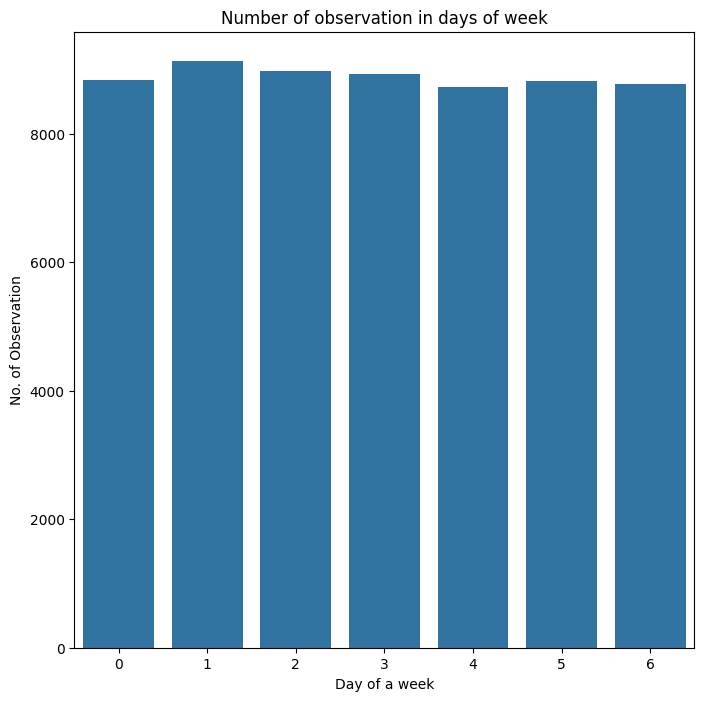

In [9]:
# plot the histogram of day of week column
plt.figure(figsize= (8,8))
sns.countplot(x = 'day_of_week', data = gym)
plt.title('Number of observation in days of week')
plt.xlabel('Day of a week')
plt.ylabel('No. of Observation')
plt.show()


All day of the weeks have similar level of observations.
`Tuesday` seems to have somewhat higher observation.

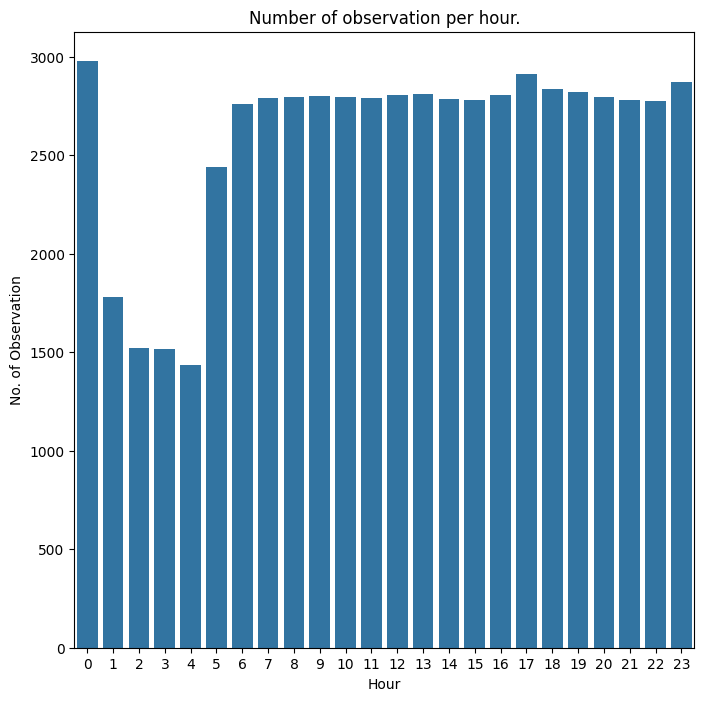

In [10]:
# plot the histogram of day of week column
plt.figure(figsize= (8,8))
sns.countplot(x = 'hour', data = gym)
plt.title('Number of observation per hour.')
plt.xlabel('Hour')
plt.ylabel('No. of Observation')
plt.show()


We can observation that the number of observations is reduced to half during `1 a.m to 5 a.m`. Other than this , we can observe similar level of observation every other hour.

Some Let's do some bivariate analysis, since our goal is to predict number so people in particular hour of a day. We will use number_people as one column during the anaysis.

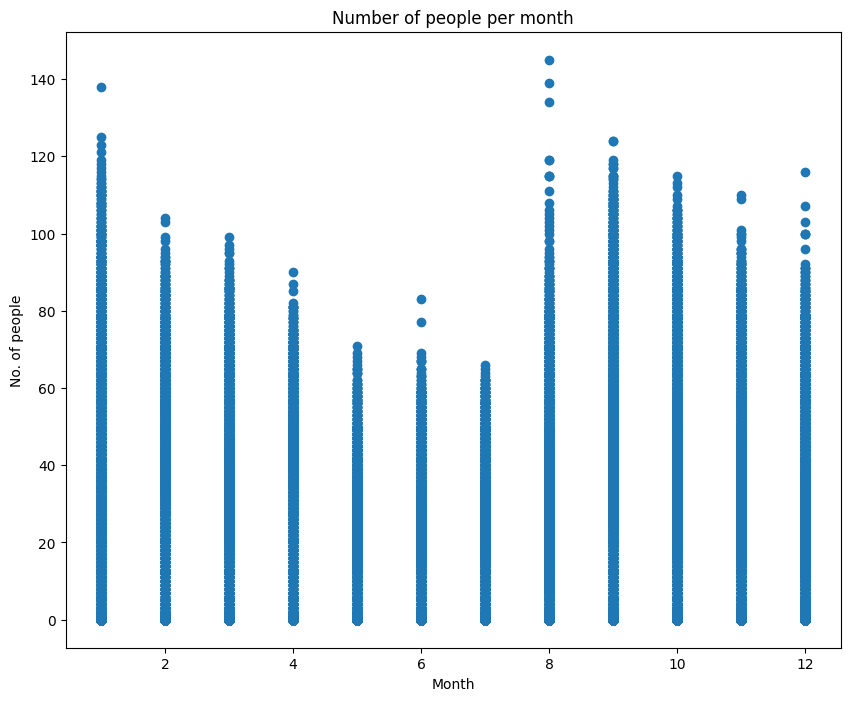

In [11]:
plt.figure(figsize = (10, 8))
plt.scatter(gym['month'], gym['number_people'])
plt.title('Number of people per month')
plt.xlabel('Month')
plt.ylabel('No. of people')
plt.show()

We can see again that August and January are the months with the bigger peaks of people, and the begining of the semester has larger peaks than the end of it.

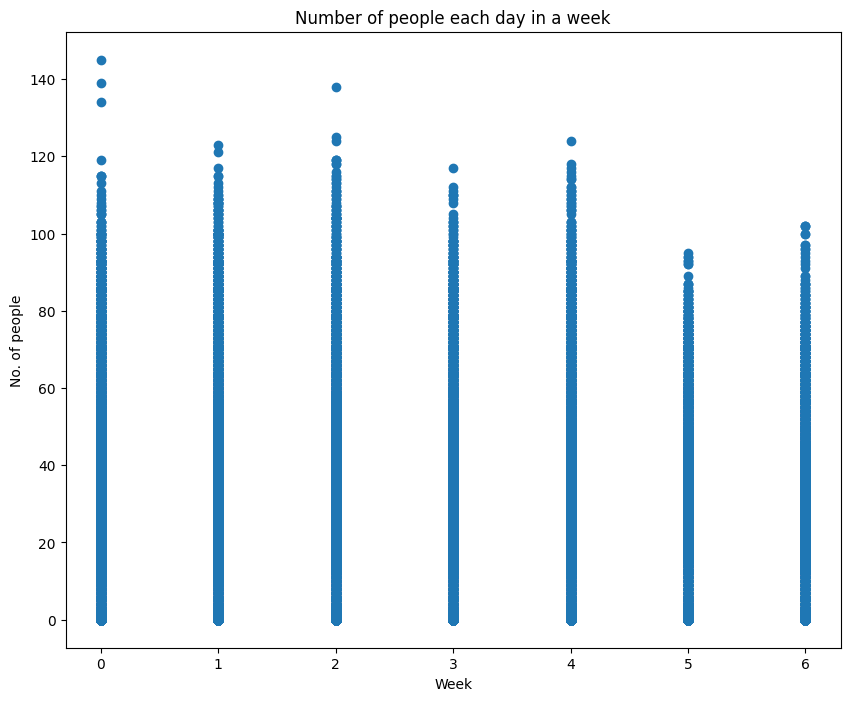

In [12]:
plt.figure(figsize = (10, 8))
plt.scatter(gym['day_of_week'], gym['number_people'])
plt.title('Number of people each day in a week')
plt.xlabel('Week')
plt.ylabel('No. of people')
plt.show()

We can observe the largest peak of monday, and lower peak of saturday.

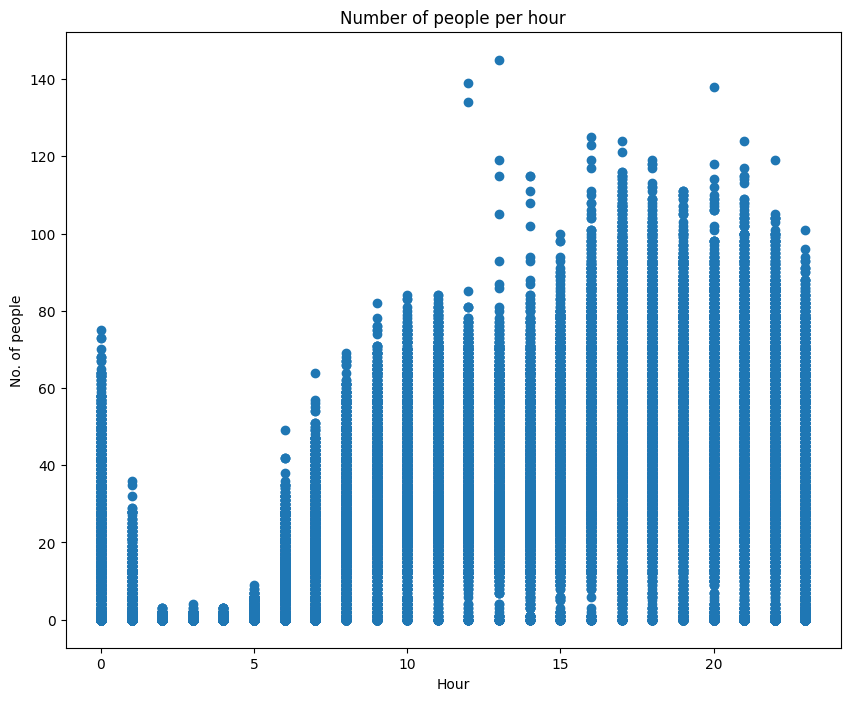

In [13]:
plt.figure(figsize = (10, 8))
plt.scatter(gym['hour'], gym['number_people'])
plt.title('Number of people per hour')
plt.xlabel('Hour')
plt.ylabel('No. of people')
plt.show()

- No. of people start increasing from 5 a.m in the gym. While it peak during evening time around 4 p.m to 5 p.m.
- In night time, the footfall of people fall rapidly.

Let's plot the correlation so we can easily select important feature from the data.

In [14]:
gym.corr()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
number_people,1.000000,0.550218,-0.162062,-0.173958,-0.048249,0.373327,0.182683,0.335350,-0.097854,0.552049
timestamp,0.550218,1.000000,-0.001793,-0.000509,0.002851,0.184849,0.009551,0.044676,-0.023221,0.999077
day_of_week,-0.162062,-0.001793,1.000000,0.791338,-0.075862,0.011169,-0.011782,-0.004824,0.015559,-0.001914
is_weekend,-0.173958,-0.000509,0.791338,1.000000,-0.031899,0.020673,-0.016646,-0.036127,0.008462,-0.000517
is_holiday,-0.048249,0.002851,-0.075862,-0.031899,1.000000,-0.088527,-0.014858,-0.070798,-0.094942,0.002843
temperature,0.373327,0.184849,0.011169,0.020673,-0.088527,1.000000,0.093242,0.152476,0.063125,0.185121
is_start_of_semester,0.182683,0.009551,-0.011782,-0.016646,-0.014858,0.093242,1.000000,0.209862,-0.137160,0.010091
is_during_semester,0.335350,0.044676,-0.004824,-0.036127,-0.070798,0.152476,0.209862,1.000000,0.096556,0.045581
month,-0.097854,-0.023221,0.015559,0.008462,-0.094942,0.063125,-0.137160,0.096556,1.000000,-0.023624
hour,0.552049,0.999077,-0.001914,-0.000517,0.002843,0.185121,0.010091,0.045581,-0.023624,1.000000


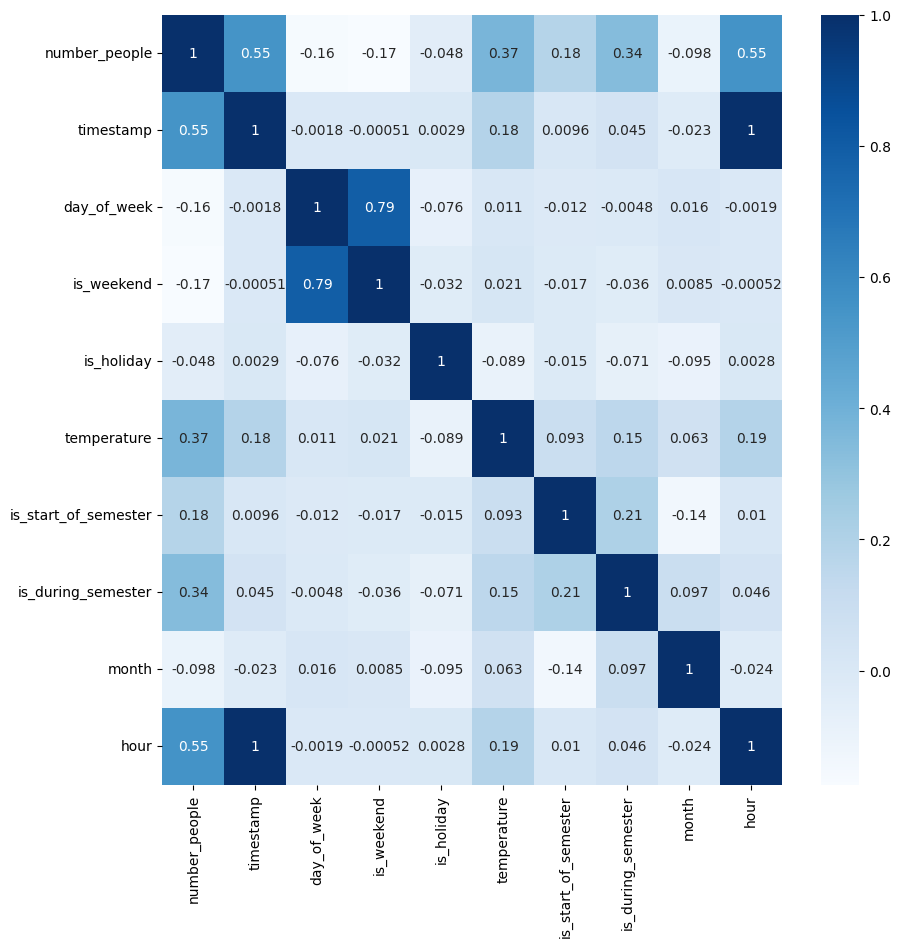

In [15]:
plt.figure(figsize = (10, 10))
sns.heatmap(gym.corr(), cmap = 'Blues', annot = True)
plt.show()

Since we are mostly interested in the number of people, we can stick to the first column of the table.

We cans see how the **hour**, **temperature** and interestingly the **is_during_semester** variables have the largest weight. Also we can see that the timestamp and hour variables have a very similar weight, wich means they could be redundant.

Other variables have weaker correlations as well, like **is_weekend** and **day_of_week** are negatively correlated which is very interesting.

Another thing, the **timestamp** seems to be redundant, since it has the same correlation as the hour, and we already have all the information on the month, day and time. So We will remove the **timestamp** column before moving on to building the model.


In [16]:
gym = gym.drop(['timestamp'],axis = 1)
gym.head()

,number_people,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,4,0,0,71.76,0,0,8,17
1,45,4,0,0,71.76,0,0,8,17
2,40,4,0,0,71.76,0,0,8,17
3,44,4,0,0,71.76,0,0,8,17
4,45,4,0,0,71.76,0,0,8,17


## Preparing to Build Our Model

In [17]:
# import necessary library for model building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

We will split the data into 80% training and 20% test data.
For the first version of the model we will not scaled the feature.

In [18]:
# Split the data into train and test set.
X = gym.drop(['number_people'], axis = 1)
y = gym['number_people']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

sdg_v1 = SGDRegressor(alpha=0.0001, learning_rate='optimal', loss='huber', 
    penalty='elasticnet', random_state = 52)
sdg_v1.fit(X_train, y_train)

SGDRegressor(learning_rate='optimal', loss='huber', penalty='elasticnet',
             random_state=52)

## Measure the Performance of the Model

In [19]:
y_pred_v1 = sdg_v1.predict(X_test)

mse = mean_squared_error(y_test, y_pred_v1)
mae = mean_absolute_error(y_test, y_pred_v1)
r2 = r2_score(y_test, y_pred_v1)

print(f'Mean squared error of model v1 :{mse}')
print(f'Mean absolute error of model v1 :{mae}')
print(f'R2 score of model v1 :{r2}')


Mean squared error of model v1 :255.83963073405585
Mean absolute error of model v1 :12.21055624314406
R2 score of model v1 :0.5049999622779815


- Mean Squared Error and Mean Absolute Error are fairly high (the closer to 0 the higher the accuracy), meaning the model is not incredibly accurate. With the R2 Score we can see there is a correlation of 0.504, wich is not terrible, but not that good either since we want it to be as close to 1 as possible.

To try and imprive the model, we can scale the features to normalize them from -1 to 1, this mught help improve the model.

In [20]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

sgd_v2 = SGDRegressor(alpha=0.0001, learning_rate='optimal', loss='huber', 
    penalty='elasticnet', random_state = 52)
sgd_v2.fit(X_train_scaled, y_train)

SGDRegressor(learning_rate='optimal', loss='huber', penalty='elasticnet',
             random_state=52)

In [21]:
y_pred_v2 = sgd_v2.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred_v2)
mae = mean_absolute_error(y_test, y_pred_v2)
r2 = r2_score(y_test, y_pred_v2)

print(f'Mean squared error of model v2 :{mse}')
print(f'Mean absolute error of model v2 :{mae}')
print(f'R2 score of model v2 :{r2}')


Mean squared error of model v2 :255.55397619510225
Mean absolute error of model v2 :12.039592415397657
R2 score of model v2 :0.5055526483772843


- We didn't observe any acutal differnce even after scaling the data. 

## Visualize the Results
A good way to understand and evaluate our models is to visualize their results. To do that, we need to plot our model's predictions from the test data, from the actual results.

Since we're using linear regression, our best bet is to use line plots.

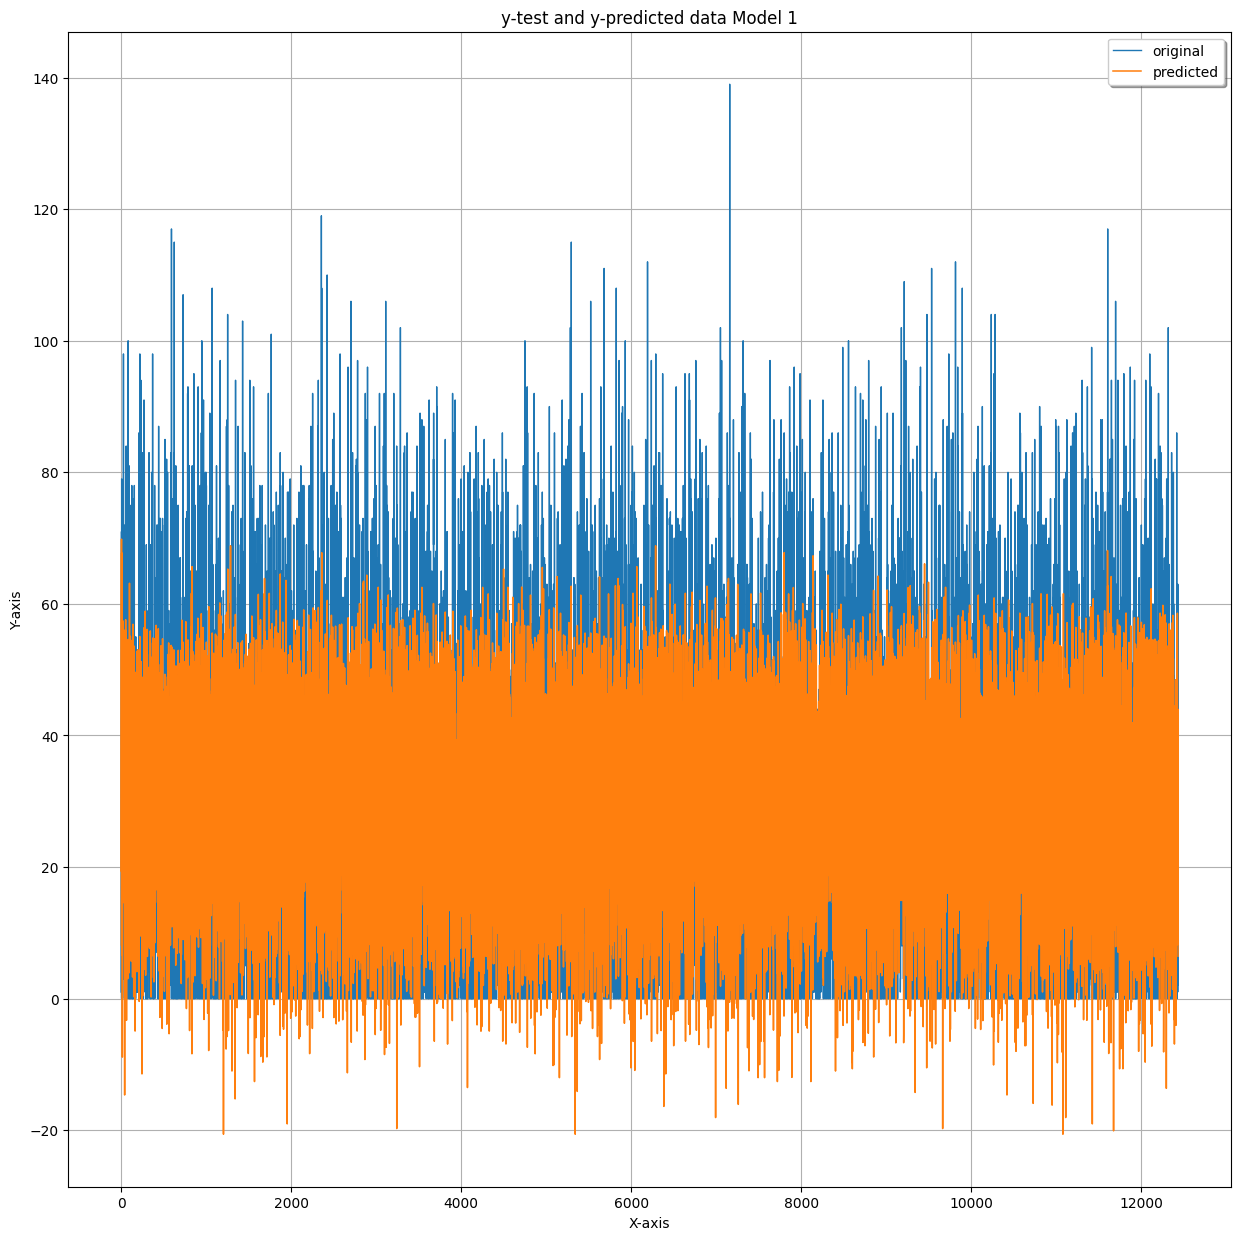

In [22]:
plt.figure(figsize=(15, 15))

x_ax = range(len(y_test))
plt.plot(x_ax, y_test, linewidth=1, label="original")
plt.plot(x_ax, y_pred_v1, linewidth=1.1, label="predicted")
plt.title("y-test and y-predicted data Model 1")
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend(loc='best',fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

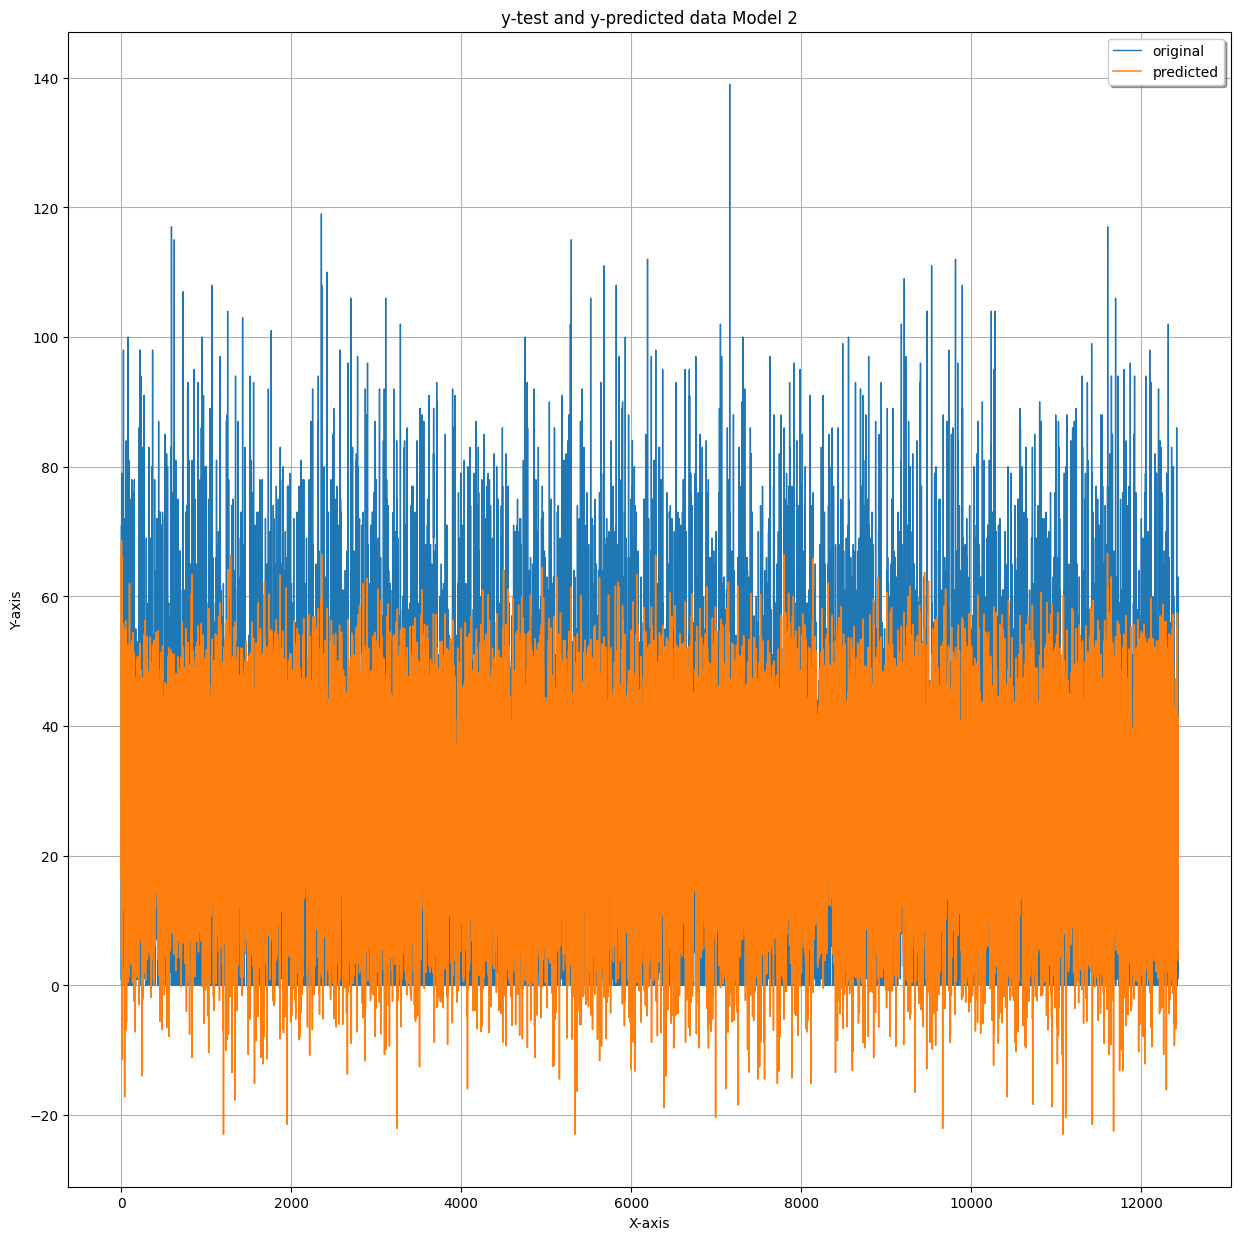

In [23]:
# Model v2

plt.figure(figsize=(15, 15))

x_ax = range(len(y_test))
plt.plot(x_ax, y_test, linewidth=1, label="original")
plt.plot(x_ax, y_pred_v2, linewidth=1.1, label="predicted")
plt.title("y-test and y-predicted data Model 2")
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend(loc='best',fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

## Summary

We can clearly see there is a lot of room for improvement. 
We can improve the model by making some changes. Regarding the data, I decided to remove the timestamp variable since I believed it to be redundant, nonetheless, maybe that redundancy might help the model get higher accuracy.

Also, I might changing and testing other hyperparameters might be interesting, especially changing the loss function from `huber` to `squared_epsilon_insensitive` and maybe exploring changing the learning rate and penalty.

In general, from the data and the model, for someone like me who likes to go to the gym often without having too many people there, any day at 5am seems like a safe bet.

